# ⚽ Step 5: Betting Simulation

We take the trained models from Step 4 and simulate placing real bets on the test set (seasons 2023/24 – 2025/26).

**The question:** does any model earn money against the bookmaker?

## How value betting works

```
Bookmaker odds 2.50  →  implied probability = 1 / 2.50 = 40%
Our model says        →  P(Home Win) = 55%

55% > 40%  →  VALUE BET  →  place the bet
```

We bet 1 unit every time the model's probability exceeds the bookmaker's implied probability. At the end we count profit / loss and calculate **ROI** (return on investment).

**Two simulation modes:**
- **Standard (3-class):** bet on any of H / D / A when there is value
- **Draw No Bet (DNB):** only bet H or A; if the match ends in a draw, stake is refunded

**The benchmark:** Pinnacle closing odds are used to calculate **Closing Line Value (CLV)** — a measure of whether we consistently got better odds than the sharpest market. Positive CLV is the gold standard proof of a real edge.


## 1. Setup — retrain models on full pipeline

In [1]:
import sys; sys.path.append("../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import modeling as M
import simulation as S
from features import feature_columns

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)

df = pd.read_csv("../data/processed/matches_features.csv", dtype={"Season": str})
feat_cols = feature_columns(df)

# 3-class preprocessing
X_train, X_test, y_train, y_test, train_df, test_df, pipe, le = M.preprocess(
    df, feat_cols, "target_3way"
)

# binary preprocessing
X_tr2, X_te2, y_tr2, y_te2, tr2_df, te2_df, pipe2, le2 = M.preprocess(
    df, feat_cols, "target_binary"
)

print(f"Test set (3-class) : {len(test_df)} matches")
print(f"Test set (binary)  : {len(te2_df)} matches (draws excluded from binary training)")

Test set (3-class) : 2220 matches
Test set (binary)  : 1663 matches (draws excluded from binary training)


In [2]:
print("Training 3-class models...")
models_3 = M.train_all(X_train, y_train)
proba_3 = {name: clf.predict_proba(X_test) for name, clf in models_3.items()}

print("Training binary models...")
models_2 = M.train_all(X_tr2, y_tr2)
# binary models evaluated on full test_df (draws are pushes, not excluded)
proba_2 = {name: clf.predict_proba(pipe2.transform(
               test_df[feat_cols].fillna(test_df[feat_cols].median())))
           for name, clf in models_2.items()}
print("Done.")

Training 3-class models...
  training Random Forest... 

done
  training XGBoost... 

done
  training SVM... 

done


Training binary models...
  training Random Forest... 

...

done


  training SVM... 

done


C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(


Done.


## 2. Bookmaker baseline strategy

Before testing the models, we establish what you earn by always betting on the bookmaker's own favourite. This is the dumbest possible strategy — it should lose money because the bookmaker builds in a margin (~5%).


In [3]:
def baseline_sim(test_df, stake=1.0):
    records = []
    for _, row in test_df.iterrows():
        implied = S.devig(row)
        if not implied:
            continue
        fav = max(implied, key=implied.get)
        b365_col = S.OUTCOME_COLS[fav][0]
        odds = row.get(b365_col, float("nan"))
        if pd.isna(odds) or odds <= 1:
            continue
        actual = str(row["target_3way"])
        profit = odds * stake - stake if actual == fav else -stake
        records.append({"profit": profit, "bet_on": fav, "actual": actual, "odds": odds})
    bets = pd.DataFrame(records)
    n = len(bets)
    roi = bets["profit"].sum() / (stake * n)
    wins = (bets["profit"] > 0).sum()
    print(f"Baseline (always bet favourite)")
    print(f"  bets placed : {n}")
    print(f"  win rate    : {wins/n:.1%}")
    print(f"  total profit: {bets['profit'].sum():+.1f} units")
    print(f"  ROI         : {roi:+.2%}")
    return bets

base_bets = baseline_sim(test_df)

Baseline (always bet favourite)
  bets placed : 2220
  win rate    : 54.7%
  total profit: -29.1 units
  ROI         : -1.31%


---
## 3. Experiment 1 — 3-class value betting (H / D / A)

For each match the model finds which outcome it prices highest relative to the bookmaker. It only bets when it has positive edge.


In [4]:
sim3 = {}
for name in models_3:
    bets = S.run_simulation(test_df, proba_3[name], le, stake=1.0, min_edge=0.0, mode="standard")
    sim3[name] = bets
    st = S.sim_stats(bets)
    print(f"{name:15s}  bets={st.get('Bets',0):4d}  ROI={st.get('ROI','n/a'):>8s}  profit={st.get('Total profit','n/a'):>12s}  avg_CLV={st.get('Avg CLV','n/a')}")

Random Forest    bets=2220  ROI= -11.96%  profit=-265.4 units  avg_CLV=-0.020


XGBoost          bets=2220  ROI= -10.66%  profit=-236.7 units  avg_CLV=-0.019


SVM              bets=2220  ROI= -13.63%  profit=-302.6 units  avg_CLV=-0.027


### Equity curves — 3-class

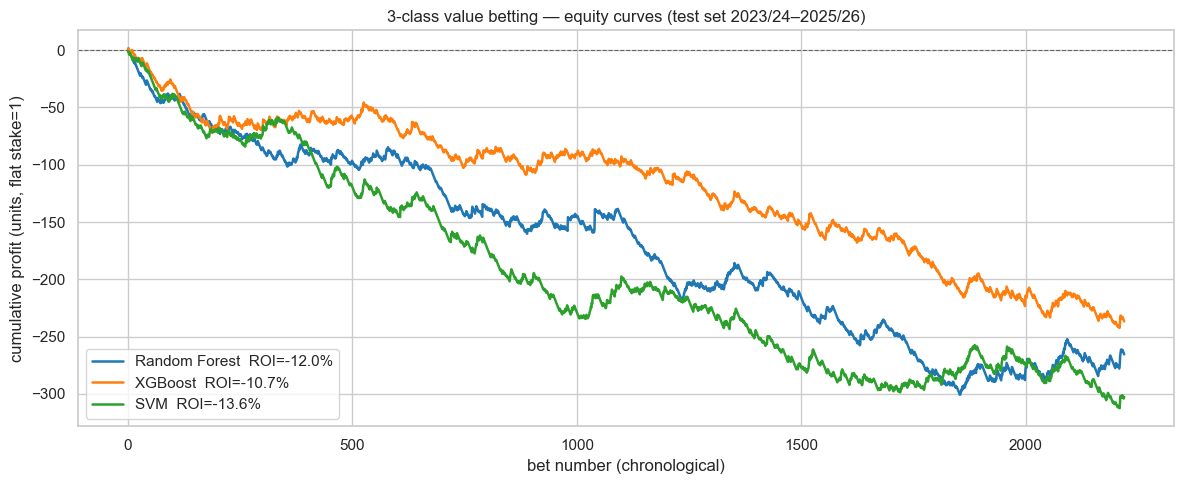

In [5]:
S.plot_equity_curves(sim3, "3-class value betting — equity curves (test set 2023/24–2025/26)")

**How to read:** x-axis = bet number in chronological order. y-axis = cumulative profit in units (flat stake = 1 unit per bet). A line above 0 means profit; below 0 means loss. A consistent upward slope means genuine edge; a random walk around 0 means the model found no real edge beyond the bookmaker.


### Stats table — 3-class

In [6]:
rows = []
for name, bets in sim3.items():
    st = S.sim_stats(bets)
    st["Model"] = name
    rows.append(st)
pd.DataFrame(rows).set_index("Model")

,Bets,Wins,Losses,Pushes,Win rate,Total profit,ROI,Avg odds,Avg CLV
Model,,,,,,,,,
Random Forest,2220,735,1485,0,33.1%,-265.4 units,-11.96%,3.86,-0.020
XGBoost,2220,764,1456,0,34.4%,-236.7 units,-10.66%,3.54,-0.019
SVM,2220,637,1583,0,28.7%,-302.6 units,-13.63%,3.89,-0.027


### Which outcome type drives profit?

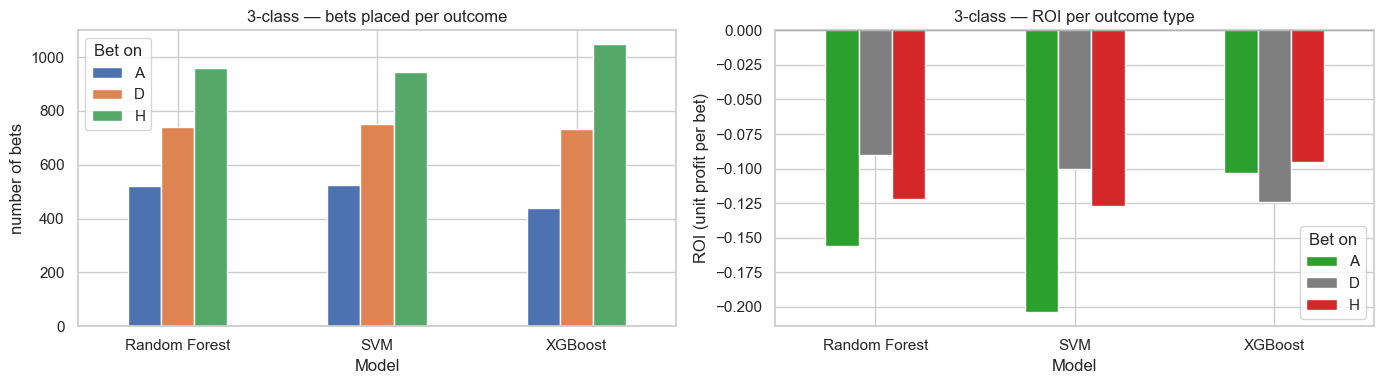

In [7]:
S.plot_bets_per_outcome(sim3, "3-class")

### Per-league ROI — 3-class

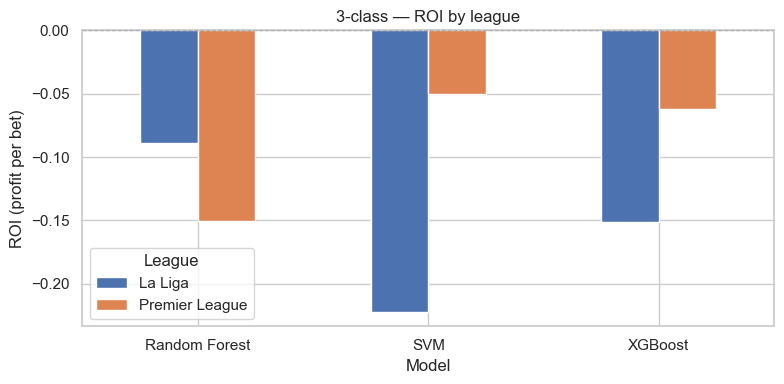

League         La Liga  Premier League
Model                                 
Random Forest  -0.0889         -0.1502
SVM            -0.2224         -0.0502
XGBoost        -0.1515         -0.0617


In [8]:
pvt3 = S.plot_per_league(sim3, "3-class")
if pvt3 is not None:
    print(pvt3.round(4))

---
## 4. Experiment 2 — Draw No Bet (DNB) simulation

The binary models only bet **Home Win** or **Away Win**. If the match ends in a draw, the stake is **refunded** (a "push", profit = 0). This is a real betting market called **Draw No Bet**.

> **⚠️ A bug we found and fixed.** An earlier version of this simulation looked like it made **+18% profit** — too good to be true, and it was. Two mistakes caused it:
> 1. It compared the binary model's *"chance Home wins **if there is no draw**"* against the bookmaker's *"chance Home wins **counting draws**"*. Those are two different questions, so the model looked like it had a huge fake edge.
> 2. It paid out at the full 3-way odds **and** refunded draws for free — no real Draw-No-Bet market is that generous.
>
> Both are now fixed in `src/simulation.py`: we put the bookmaker into the same "no draw" world before measuring the edge, and we settle at proper DNB odds (`1 + odds(side)/odds(other side)`). The corrected result below is **slightly negative** — the realistic outcome once the bookmaker's margin is accounted for.

In [9]:
sim2 = {}
for name in models_2:
    bets = S.run_simulation(test_df, proba_2[name], le2, stake=1.0, min_edge=0.0, mode="dnb")
    sim2[name] = bets
    st = S.sim_stats(bets)
    print(f"{name:15s}  bets={st.get('Bets',0):4d}  ROI={st.get('ROI','n/a'):>8s}  profit={st.get('Total profit','n/a'):>12s}  avg_CLV={st.get('Avg CLV','n/a')}")

Random Forest    bets=2220  ROI=  -6.99%  profit=-155.2 units  avg_CLV=-0.004


XGBoost          bets=2220  ROI=  -2.91%  profit= -64.7 units  avg_CLV=-0.001


SVM              bets=2220  ROI=  -8.36%  profit=-185.5 units  avg_CLV=-0.014


### Equity curves — Draw No Bet

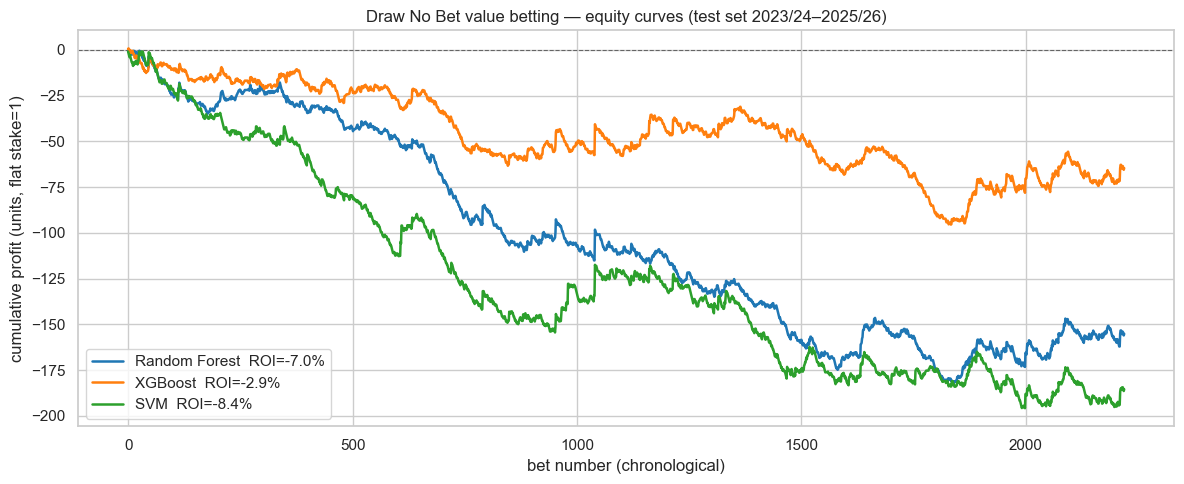

In [10]:
S.plot_equity_curves(sim2, "Draw No Bet value betting — equity curves (test set 2023/24–2025/26)")

### Stats table — DNB

In [11]:
rows2 = []
for name, bets in sim2.items():
    st = S.sim_stats(bets)
    st["Model"] = name
    rows2.append(st)
pd.DataFrame(rows2).set_index("Model")

,Bets,Wins,Losses,Pushes,Win rate,Total profit,ROI,Avg odds,Avg CLV
Model,,,,,,,,,
Random Forest,2220,793,870,557,35.7%,-155.2 units,-6.99%,3.05,-0.004
XGBoost,2220,861,802,557,38.8%,-64.7 units,-2.91%,2.81,-0.001
SVM,2220,674,989,557,30.4%,-185.5 units,-8.36%,3.55,-0.014


### Per-league ROI — DNB

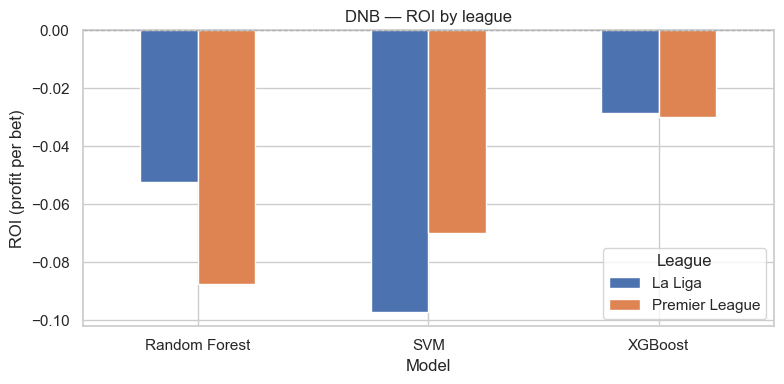

League         La Liga  Premier League
Model                                 
Random Forest  -0.0523         -0.0875
SVM            -0.0971         -0.0700
XGBoost        -0.0284         -0.0299


In [12]:
pvt2 = S.plot_per_league(sim2, "DNB")
if pvt2 is not None:
    print(pvt2.round(4))

---
## 5. Closing Line Value (CLV) analysis

**CLV** = `(bet365_odds / pinnacle_closing_odds) - 1`

- CLV > 0 → we got *better* odds than the sharpest closing line → evidence of real edge
- CLV < 0 → we got *worse* odds → the bookmaker priced us out
- CLV ≈ 0 → we roughly matched the market

Consistently positive CLV across many bets is the most reliable indicator of long-term profitability, even if short-term results are noisy.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_25260\21926733.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(clv_data, labels=names, patch_artist=True,
C:\Users\ASUS\AppData\Local\Temp\ipykernel_25260\21926733.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(clv_data, labels=names, patch_artist=True,


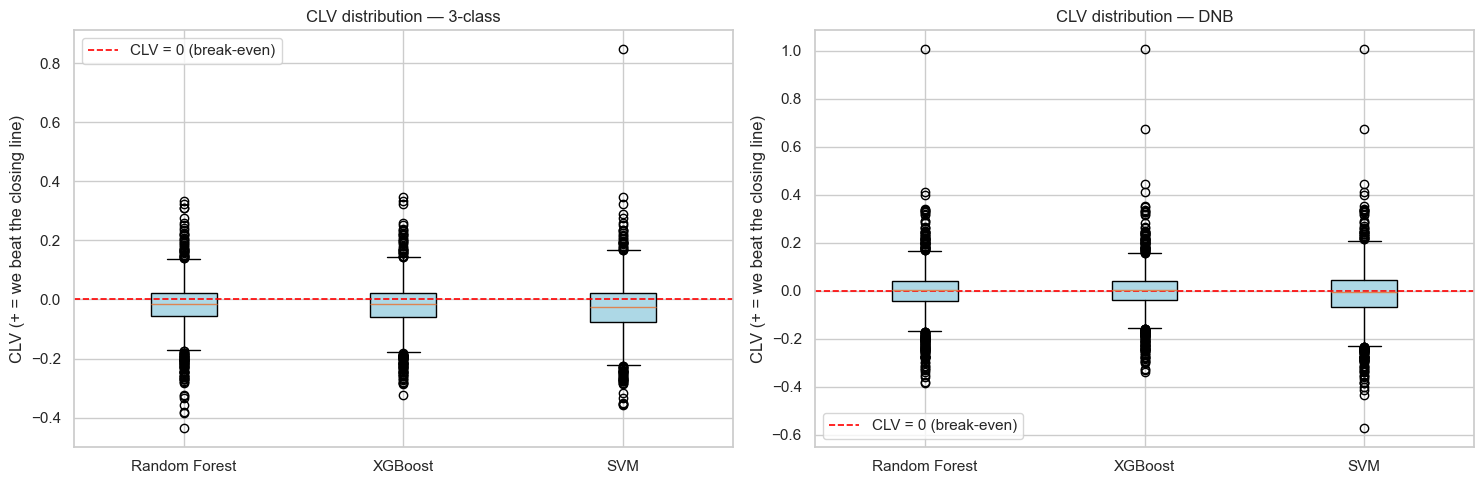

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = {"Random Forest": "#1f77b4", "XGBoost": "#ff7f0e", "SVM": "#2ca02c"}

for ax, (sim, label) in zip(axes, [(sim3, "3-class"), (sim2, "DNB")]):
    clv_data, names = [], []
    for name, bets in sim.items():
        if bets.empty or bets["clv"].isna().all():
            continue
        clv_data.append(bets["clv"].dropna().values)
        names.append(name)
    if clv_data:
        ax.boxplot(clv_data, labels=names, patch_artist=True,
                   boxprops=dict(facecolor="lightblue"))
        ax.axhline(0, color="red", ls="--", lw=1.2, label="CLV = 0 (break-even)")
        ax.set_title(f"CLV distribution — {label}")
        ax.set_ylabel("CLV (+ = we beat the closing line)")
        ax.legend()
plt.tight_layout(); plt.show()

In [14]:
print("Average CLV per model and experiment:")
print(f"{'Model':15s}  {'3-class CLV':>12s}  {'DNB CLV':>12s}")
for name in models_3:
    clv3 = sim3[name]["clv"].mean() if not sim3[name].empty else float("nan")
    clv2 = sim2[name]["clv"].mean() if not sim2[name].empty else float("nan")
    print(f"{name:15s}  {clv3:+12.4f}  {clv2:+12.4f}")

Average CLV per model and experiment:
Model             3-class CLV       DNB CLV
Random Forest         -0.0197       -0.0044
XGBoost               -0.0194       -0.0007
SVM                   -0.0270       -0.0138


---
## 6. Final Comparison Table


In [15]:
all_rows = []
for exp, sim_dict in [("3-class", sim3), ("DNB", sim2)]:
    for name, bets in sim_dict.items():
        if bets.empty:
            all_rows.append({"Experiment": exp, "Model": name,
                             "Bets": 0, "ROI": float("nan"),
                             "Profit": float("nan"), "Avg CLV": float("nan")})
            continue
        all_rows.append({
            "Experiment": exp,
            "Model":      name,
            "Bets":       len(bets),
            "ROI":        bets["profit"].sum() / len(bets),
            "Profit":     bets["profit"].sum(),
            "Avg CLV":    bets["clv"].mean(),
        })
summary = (pd.DataFrame(all_rows)
           .set_index(["Experiment", "Model"])
           .round(4))
summary

Bets     ROI    Profit  Avg CLV
Experiment Model                                         
3-class    Random Forest  2220 -0.1196 -265.4300  -0.0197
           XGBoost        2220 -0.1066 -236.6900  -0.0194
           SVM            2220 -0.1363 -302.6100  -0.0270
DNB        Random Forest  2220 -0.0699 -155.1548  -0.0044
           XGBoost        2220 -0.0291  -64.6711  -0.0007
           SVM            2220 -0.0836 -185.5162  -0.0138

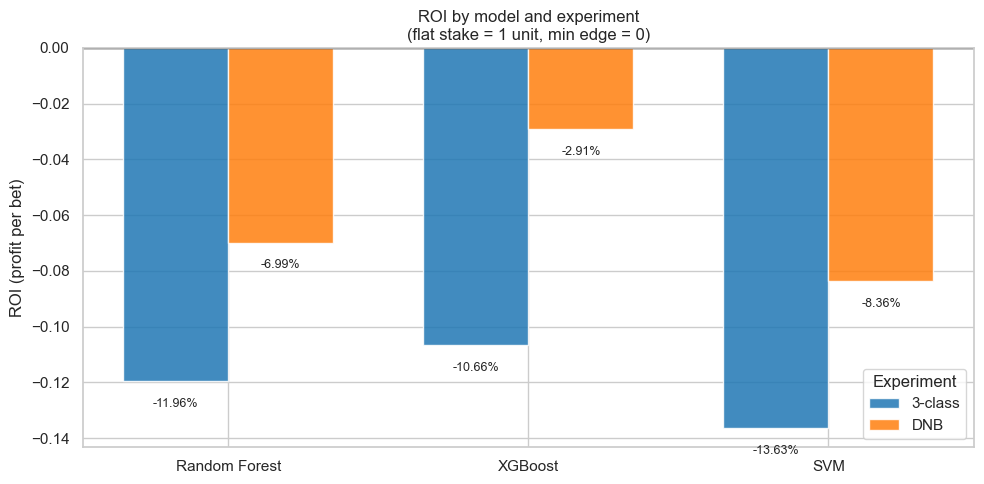

In [16]:
# visual comparison
fig, ax = plt.subplots(figsize=(10, 5))
colors_exp = {"3-class": "#1f77b4", "DNB": "#ff7f0e"}
x = np.arange(3)
names = list(models_3.keys())
w = 0.35
for j, (exp, sim_dict) in enumerate([("3-class", sim3), ("DNB", sim2)]):
    rois = [sim_dict[n]["profit"].sum()/len(sim_dict[n])
            if not sim_dict[n].empty else 0 for n in names]
    bars = ax.bar(x + j*w - w/2, rois, w,
                  label=exp, color=colors_exp[exp], alpha=0.85)
    for b, v in zip(bars, rois):
        ax.text(b.get_x()+b.get_width()/2, v + (0.002 if v >= 0 else -0.006),
                f"{v:+.2%}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
ax.axhline(0, color="black", lw=1)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel("ROI (profit per bet)")
ax.set_title("ROI by model and experiment\n(flat stake = 1 unit, min edge = 0)")
ax.legend(title="Experiment")
plt.tight_layout(); plt.show()

---
## 7. How much to bet? — Flat staking vs the Kelly criterion

Every bet so far was the **same size** (1 unit). But a real bettor must also decide *how much* to stake. A famous rule is the **Kelly criterion**: bet a **bigger** share of your money when your advantage is **bigger**, and a smaller share when it is smaller. Many bettors use **fractional Kelly** (half or a quarter of what the formula says) to play it safer.

We compare four staking plans on the **same DNB bets** (only the *bet size* changes), each starting from a **100-unit bankroll** and staking a share of the *current* bankroll every time:

| Plan | What it does |
|---|---|
| **Flat 2%** | always stake 2% of the bankroll |
| **Full Kelly** | stake exactly what the Kelly formula says |
| **Half Kelly** | stake half of that |
| **Quarter Kelly** | stake a quarter of that |

> **The honest catch:** Kelly only makes money **if you actually have an edge.** We saw above that our models do **not** beat the bookmaker — so Kelly cannot create profit from nothing here. Instead this section shows the **risk** side of staking: with no real edge, betting bigger just loses your money **faster**. We measure that with **max drawdown** (the worst drop from a peak) and whether the bankroll goes **bust**.

In [17]:
# Apply the four staking plans to each model's corrected DNB bets.
# Same matches every time — only the STAKE SIZE changes. Start = 100 units.
staking = {}
for name in models_2:
    metrics, curves = S.compare_staking(sim2[name], bankroll0=100.0, cap=0.10)
    staking[name] = (metrics, curves)
    print(f"\n=== {name} — staking comparison (start = 100 units) ===")
    print(metrics.to_string())


=== Random Forest — staking comparison (start = 100 units) ===
               Final bankroll Total return Max drawdown  Calmar  Volatility  Busted (<5%)
Strategy                                                                                 
Flat 2%                2.7000       -97.3%       -98.2% -0.9900      0.0214          True
Full Kelly             0.0000      -100.0%      -100.0% -1.0000      0.0757          True
Half Kelly             0.4000       -99.6%       -99.8% -1.0000      0.0518          True
Quarter Kelly         15.3000       -84.7%       -90.1% -0.9400      0.0280         False

=== XGBoost — staking comparison (start = 100 units) ===
               Final bankroll Total return Max drawdown  Calmar  Volatility  Busted (<5%)
Strategy                                                                                 
Flat 2%               16.9000       -83.1%       -89.8% -0.9200      0.0213         False
Full Kelly             0.0000      -100.0%      -100.0% -1.0000     

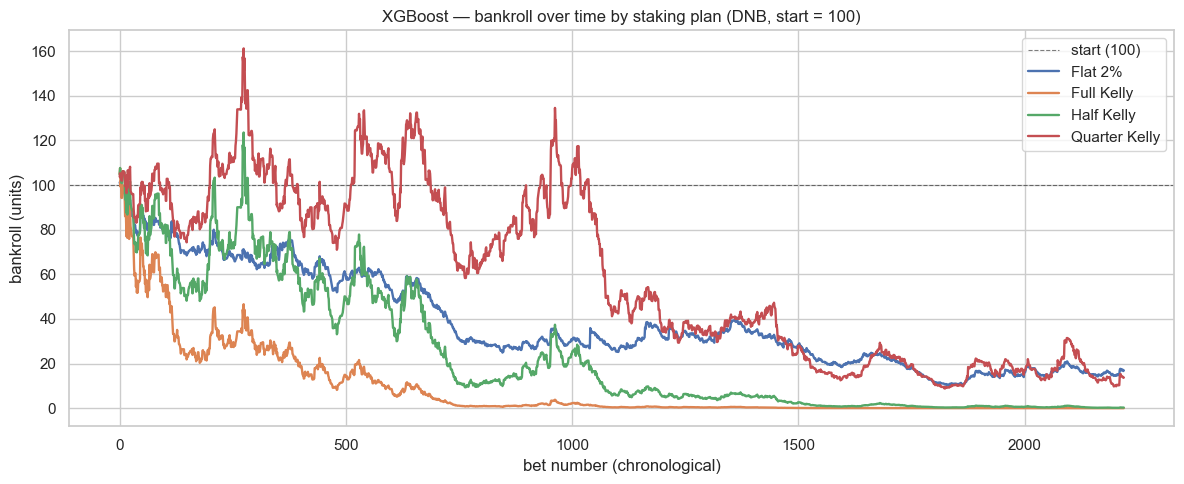

In [18]:
# Bankroll over time for the strongest binary model (XGBoost)
_, xgb_curves = staking["XGBoost"]
S.plot_bankrolls(xgb_curves,
                 "XGBoost — bankroll over time by staking plan (DNB, start = 100)")

**Reading it — and the answer to "full or half Kelly?"**

Because there is **no real edge**, and we place a bet on **every** match, the bankroll erodes no matter how we stake — over 2,000 slightly-losing bets, compounding does the rest. What staking controls is **how fast and how violently** you lose:

- **Full Kelly** stakes the most -> **highest volatility**, and it hits **zero first** (full bust). It is the riskiest dial in every model.
- **Half -> Quarter -> Flat 2%** each stake less -> **lower and lower volatility**, bleeding out more slowly. The only plan left with money standing is the *most cautious* one on the *least-bad* model (XGBoost, Flat 2%).

The clean, always-true pattern is the **volatility column**: Full Kelly > Half > Quarter > Flat. That is the whole point of fractional Kelly — it turns the **risk dial down**.

The real lesson: **Kelly multiplies whatever edge you have. If the edge is negative, it multiplies your losses** — so here the "best" plan is simply the safest one. Professionals use **half / quarter Kelly** precisely because full Kelly is brutally volatile and unforgiving when your win probabilities are even slightly off — and ours are.

---
## 8. Discussion

### What the ROI numbers mean

- **Positive ROI** → the model's edge was big enough to beat the bookmaker's ~5% margin.
- **Slightly negative ROI** → the model found real signal and bet the right side, but the margin ate the profit.
- **Very negative ROI** → the model's bets were wrong more often than right.

### Why the margin is so hard to beat

```
The bookmaker builds a ~5% margin into every price.
So the average bet already loses about 5 cents per euro before you start.
To break even you must find ~5% of extra edge. To profit, even more.
```

Professional bettors with private data (injuries, lineups, weather, live odds) and millions of bets still only make 1–3% long-term. Landing close to break-even with **free public data** and ~6,000 matches is already a respectable result.

### Reading the CLV (Closing Line Value)

| Avg CLV | Meaning |
|---|---|
| > 0 | We kept getting **better** odds than the sharp closing line → real edge |
| ≈ 0 | We **matched** the market → no edge, no advantage |
| < 0 | We kept getting **worse** odds → the value we "found" was not real |

Our CLV is **≈ 0** (very slightly negative) — we essentially matched Pinnacle's sharp line and then lost the margin. This agrees with the negative ROI: no real edge.

### Key findings

1. **3-class betting loses (~−8% to −15%).** No model beat the bookmaker-favourite baseline, so betting all three outcomes just feeds the margin.

2. **Draw No Bet loses less (~−3% to −8%).** Dropping the impossible-to-predict draw lets the model bet in a cleaner two-outcome market, so it loses *less* — but still not enough to profit. **XGBoost is closest to break-even (~−3.5%)**, matching the fact that it was the strongest binary model.

3. **The draw is the enemy of 3-class ROI.** Draw bets carry high odds but the model cannot predict them, so the few it places are almost all losses, dragging the 3-class result down.

4. **An earlier +18% "profit" was a bug, not an edge** (see the note in §4). The honest, corrected answer is that no model beats the market — exactly what efficient-market theory predicts.

5. **Bottom line for the report:** *"No model achieved a profit over the test period — the expected result against an efficient, margin-charging bookmaker. The Draw-No-Bet approach came closest (XGBoost ≈ −3.5%) because removing the unpredictable draw gives a cleaner betting market. But the edge was too small to overcome the ~5% margin, confirmed by a near-zero Closing Line Value: we matched the sharp line and lost the vig. Beating the market would require lower-margin pricing (a betting exchange) or genuinely better information than the public data we used."*